# Treinamento Supervisionado por Classificação

In [174]:
import pandas as pd
import numpy as np

In [175]:
df = pd.read_csv("../data/silver/flights_delay_cancelled.csv", sep=",")
df.head()

,DAY_OF_WEEK,AIRLANE_CODE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,ORIGIN_STATE_NAME,ORIGIN_COUNTRY_NAME,ORIGIN_LATITUDE_NAME,ORIGIN_LONGITUDE_NAME,DESTINATION_AIRPORT_NAME,DESTINATION_CITY_NAME,DESTINATION_STATE_NAME,DESTINATION_COUNTRY_NAME,DESTINATION_LATITUDE_NAME,DESTINATION_LONGITUDE_NAME
0,4,AS,98,N407AS,ANC,SEA,5,2354,-11.0,21.0,...,AK,USA,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931
1,4,AA,2336,N3KUAA,LAX,PBI,10,2,-8.0,12.0,...,CA,USA,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559
2,4,US,840,N171US,SFO,CLT,20,18,-2.0,16.0,...,CA,USA,37.61900,-122.37484,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
3,4,AA,258,N3HYAA,LAX,MIA,20,15,-5.0,15.0,...,CA,USA,33.94254,-118.40807,Miami International Airport,Miami,FL,USA,25.79325,-80.29056
4,4,AS,135,N527AS,SEA,ANC,25,24,-1.0,11.0,...,WA,USA,47.44898,-122.30931,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619


#### Considero como atraso valores acima de 15 minutos, padrão aviação

In [176]:
df["ATRASO"] = (df["DEPARTURE_DELAY"] > 15).astype(int)

df[["DEPARTURE_DELAY", "ATRASO"]]

,DEPARTURE_DELAY,ATRASO
0,-11.0,0
1,-8.0,0
2,-2.0,0
3,-5.0,0
4,-1.0,0
...,...,...
5332909,-4.0,0
5332910,-4.0,0
5332911,-9.0,0
5332912,-6.0,0


In [177]:
df["ATRASO"].unique()

array([0, 1])

In [178]:
df["HOUR"] = df["SCHEDULED_DEPARTURE"] // 100
df["HOUR_SIN"] = np.sin(2*np.pi*df["HOUR"]/24)
df["HOUR_COS"] = np.cos(2*np.pi*df["HOUR"]/24)


In [179]:
features = [
    "DAY_OF_WEEK",
    "AIRLANE_CODE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_DEPARTURE",
    "DISTANCE_KM"
]

X = df[features]
y = df["ATRASO"]

In [180]:
X.shape

(5332914, 6)

In [181]:
X.isna().sum()

DAY_OF_WEEK            0
AIRLANE_CODE           0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_DEPARTURE    0
DISTANCE_KM            0
dtype: int64

In [182]:
X.dtypes

DAY_OF_WEEK              int64
AIRLANE_CODE            object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DISTANCE_KM            float64
dtype: object

## Inicio Treinamento

In [183]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [184]:
# Colunas de variáveis numéricas e categóricas
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

cat_cols = X.select_dtypes(include=["object"]).columns

In [185]:
num_cols, cat_cols

(Index(['DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DISTANCE_KM'], dtype='object'),
 Index(['AIRLANE_CODE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'], dtype='object'))

In [186]:
cat_validation = X[['AIRLANE_CODE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']]

In [187]:
# Valido aqui se possui algum valor estranho, como por exemplo um código de aeroporto que não existe
cat_validation["DESTINATION_AIRPORT"].unique()

array(['SEA', 'PBI', 'CLT', 'MIA', 'ANC', 'MSP', 'DFW', 'ATL', 'IAH',
       'PDX', 'MCI', 'FLL', 'ORD', 'HNL', 'PHX', 'EWR', 'JFK', 'MCO',
       'BOS', 'BDL', 'ITO', 'SFO', 'KOA', 'OGG', 'MYR', 'DTW', 'LIH',
       'DEN', 'SJU', 'LAX', 'BWI', 'IAD', 'BQN', 'BUF', 'LGA', 'HOU',
       'SLC', 'PHL', 'SJC', 'OAK', 'LGB', 'TPA', 'DCA', 'TTN', 'BTR',
       'LAS', 'RSW', 'BRD', 'STL', 'RKS', 'MBS', 'SNA', 'MEI', 'MDW',
       'SAN', 'RIC', 'AUS', 'OTZ', 'PIT', 'JAX', 'MSY', 'ONT', 'PSP',
       'BUR', 'DAL', 'CVG', 'SMF', 'RDU', 'JMS', 'BNA', 'DSM', 'MAF',
       'BOI', 'ELP', 'TUS', 'SCC', 'HPN', 'STT', 'MDT', 'RHI', 'SBP',
       'MKE', 'JNU', 'CMH', 'CLD', 'KTN', 'CAK', 'CRP', 'CLE', 'GPT',
       'SHV', 'TYS', 'IND', 'LIT', 'SAT', 'SRQ', 'TUL', 'GRK', 'PNS',
       'BTV', 'CHS', 'DAY', 'OKC', 'SAV', 'XNA', 'COS', 'GJT', 'BZN',
       'PUB', 'HRL', 'HDN', 'MEM', 'GEG', 'ORH', 'SYR', 'GSO', 'VPS',
       'LAW', 'ACY', 'LBB', 'JAC', 'BIL', 'EUG', 'ASE', 'TVC', 'MTJ',
       'CAE', 'PVD',

In [188]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [189]:
preprocess

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [190]:
model = LogisticRegression(max_iter=1000, class_weight="balanced", C=1.0)

In [191]:
pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", model)
    ]
)

In [192]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [193]:
X_train

,DAY_OF_WEEK,AIRLANE_CODE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DISTANCE_KM
688190,7,DL,SFO,JFK,1345,4162.0
2083173,3,EV,ABE,ORD,707,1053.0
4207718,6,HA,HNL,LIH,1523,164.0
1980733,3,VX,SEA,LAX,1740,1535.0
4953624,1,AA,DFW,MSY,1345,719.0
...,...,...,...,...,...,...
3230675,2,AA,ORD,JFK,1308,1191.0
4283333,4,AS,SEA,DFW,1300,2672.0
1487618,1,AA,MIA,SAN,920,3648.0
334427,4,MQ,DCA,JFK,1935,343.0


In [194]:
y_train

688190     0
2083173    0
4207718    0
1980733    0
4953624    0
          ..
3230675    0
4283333    0
1487618    0
334427     1
3844558    0
Name: ATRASO, Length: 4266331, dtype: int64

In [195]:
pipeline.fit(X_train, y_train)

/Users/viniciussouza/Codes/FIAP/FIAP_projeto_Fase_3/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [196]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = pipeline.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[530141 344277]
 [ 72324 119841]]
              precision    recall  f1-score   support

           0       0.88      0.61      0.72    874418
           1       0.26      0.62      0.37    192165

    accuracy                           0.61   1066583
   macro avg       0.57      0.61      0.54   1066583
weighted avg       0.77      0.61      0.65   1066583



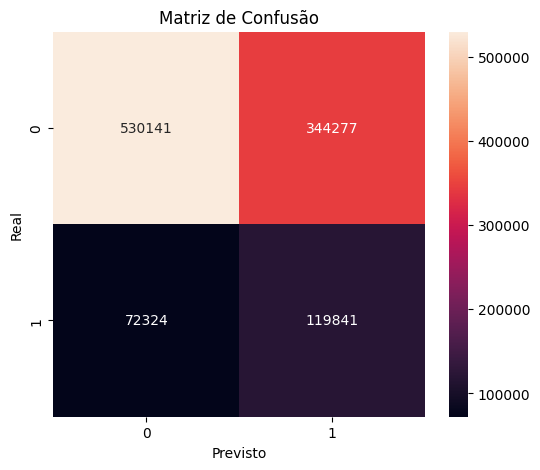

In [197]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

In [198]:
# Adicionando um novo voo para teste de previsão

novo_voo = pd.DataFrame({
    "DAY_OF_WEEK": [5],
    "AIRLANE_CODE": ["AA"],
    "ORIGIN_AIRPORT": ["JFK"],
    "DESTINATION_AIRPORT": ["LAX"],
    "SCHEDULED_DEPARTURE": [1430],
    "DISTANCE_KM": [3974]
})

In [200]:
pipeline.predict(novo_voo)

array([1])

In [209]:
novo_voo_1 = pd.DataFrame({
    "DAY_OF_WEEK": [1],
    "AIRLANE_CODE": ["AA"],
    "ORIGIN_AIRPORT": ["JFK"],
    "DESTINATION_AIRPORT": ["LAX"],
    "SCHEDULED_DEPARTURE": [1430],
    "DISTANCE_KM": [3974]
})

In [205]:
pipeline.predict(novo_voo_1)

array([1])